In [1]:
from mfpy.utils import label_series
from mfpy.clustering import SegmentBasedCluster
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import deeptime

filename = "../../../data/Langevin/langevin.txt"
data = np.loadtxt(filename)
data = np.reshape(data, (data.shape[0], 1))


In [2]:
T = data.shape[0]
l = 0*T
u = 25000
x = data[l:u]
w=np.array([215])
q=np.array([0.86])
cp_sbc = SegmentBasedCluster(window_size=w, quantile=q)
cp_sbc.fit(x)

100%|███████████████████████████████████████| 861/861 [00:00<00:00, 7101.18it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


SegmentBasedCluster(quantile=array([0.86]), window_size=array([215]))

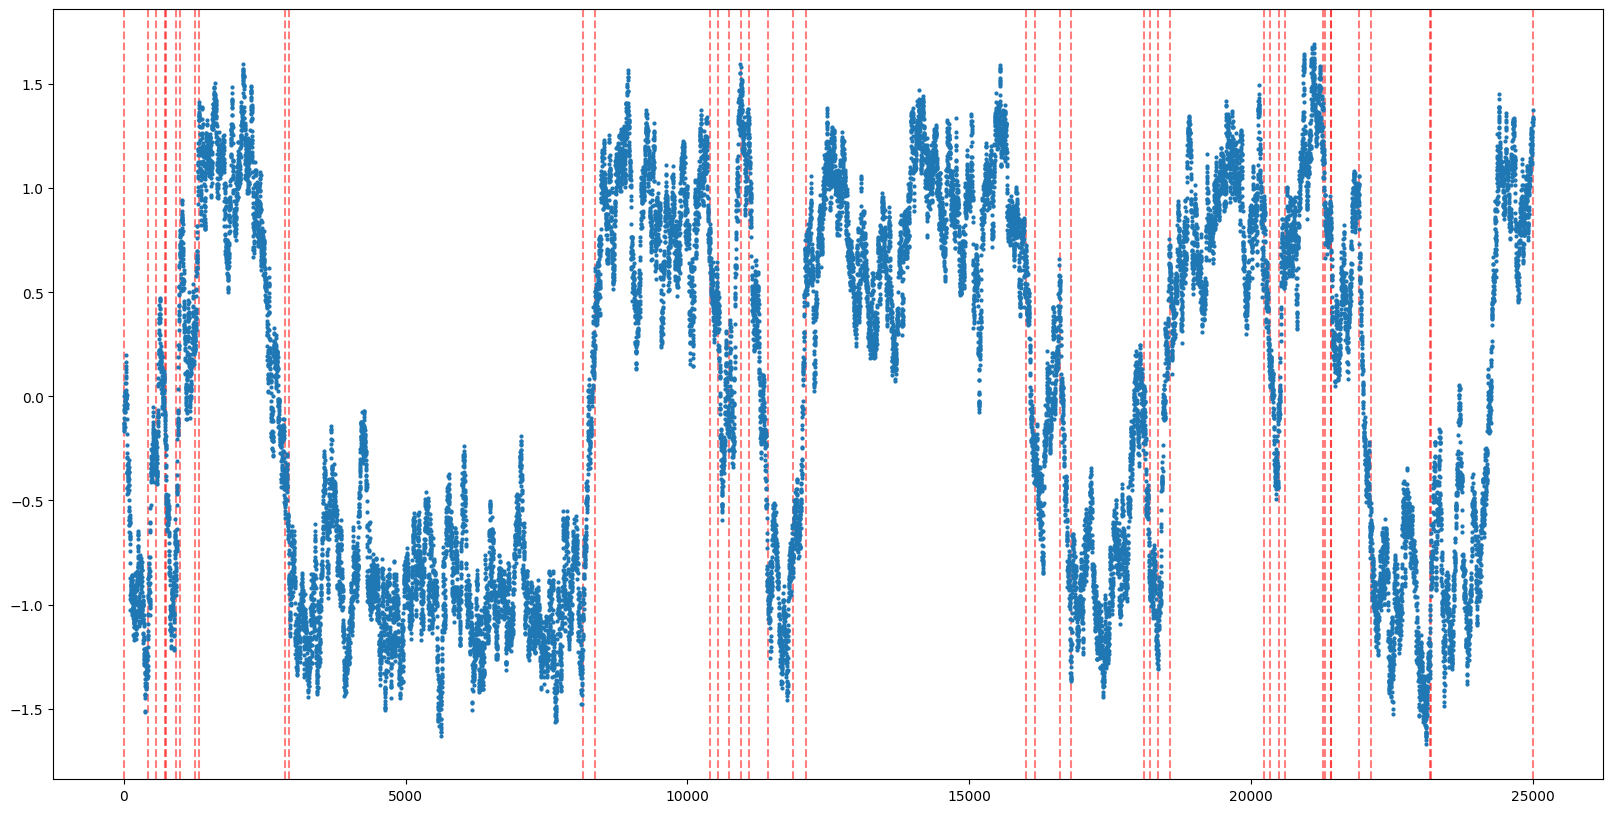

In [4]:
cp_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": cp_sbc.point_labels_})
cps = cp_sbc.change_points_[:,0]
df = cp_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = df['label'].value_counts().head(N).index
plt.scatter(df['time'], df['value'], s=4, rasterized=True)
for t in df['time'][cps == 1]:
    plt.axvline(t, color='red', linestyle='--', alpha=0.5, zorder=0)
plt.savefig("langevin-cps.pdf")
plt.show()

In [6]:
x = data
K=3
# fit wit SC
sc_sbc = SegmentBasedCluster(window_size=w, quantile=q, method="spectral", num_clusters=K)
sc_sbc.fit(x)
segment_labels = sc_sbc.segment_labels_
labels = sc_sbc.point_labels_
sc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

# refit with ADPC
adpc_sbc = SegmentBasedCluster(window_size=w, quantile=q)
adpc_sbc.fit(x)
segment_labels = adpc_sbc.segment_labels_
labels = adpc_sbc.point_labels_
adpc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

100%|███████████████████████████████████| 12246/12246 [00:01<00:00, 7450.33it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


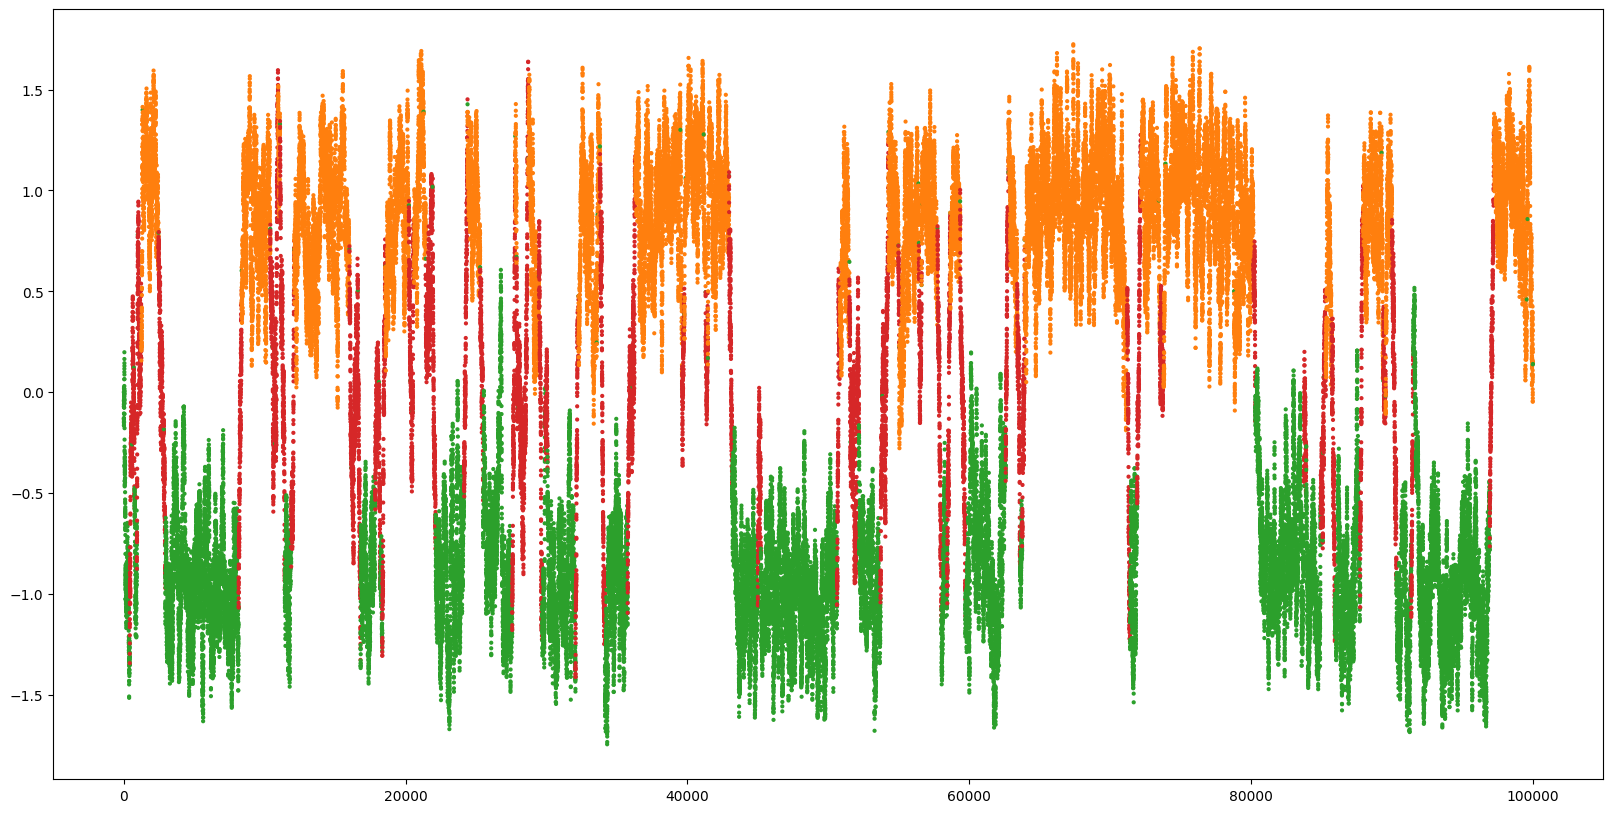

In [7]:
data = sc_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("langevin-spectral-clustering.pdf")
plt.show()

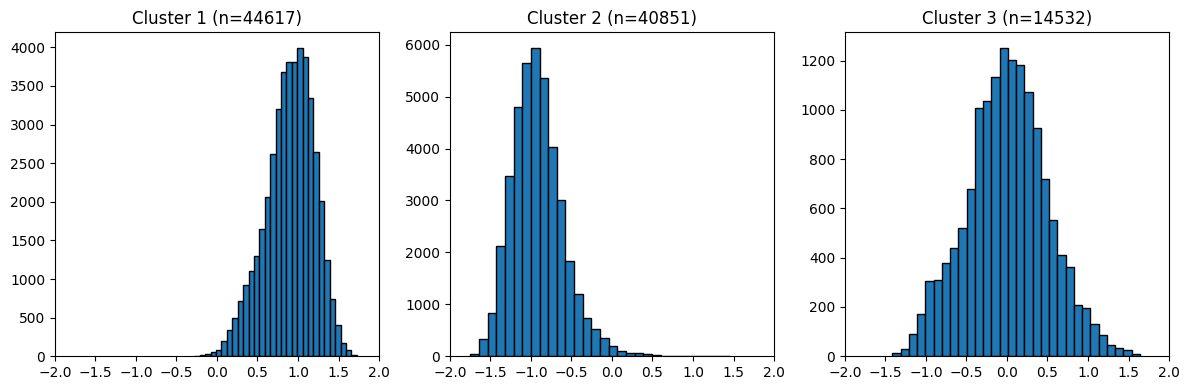

In [8]:
N = 3
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1,3, figsize=(12, 4))
ticks = [-2.0 + n*0.5 for n in range(9)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("langevin-spectral-distributions.pdf")
plt.show()

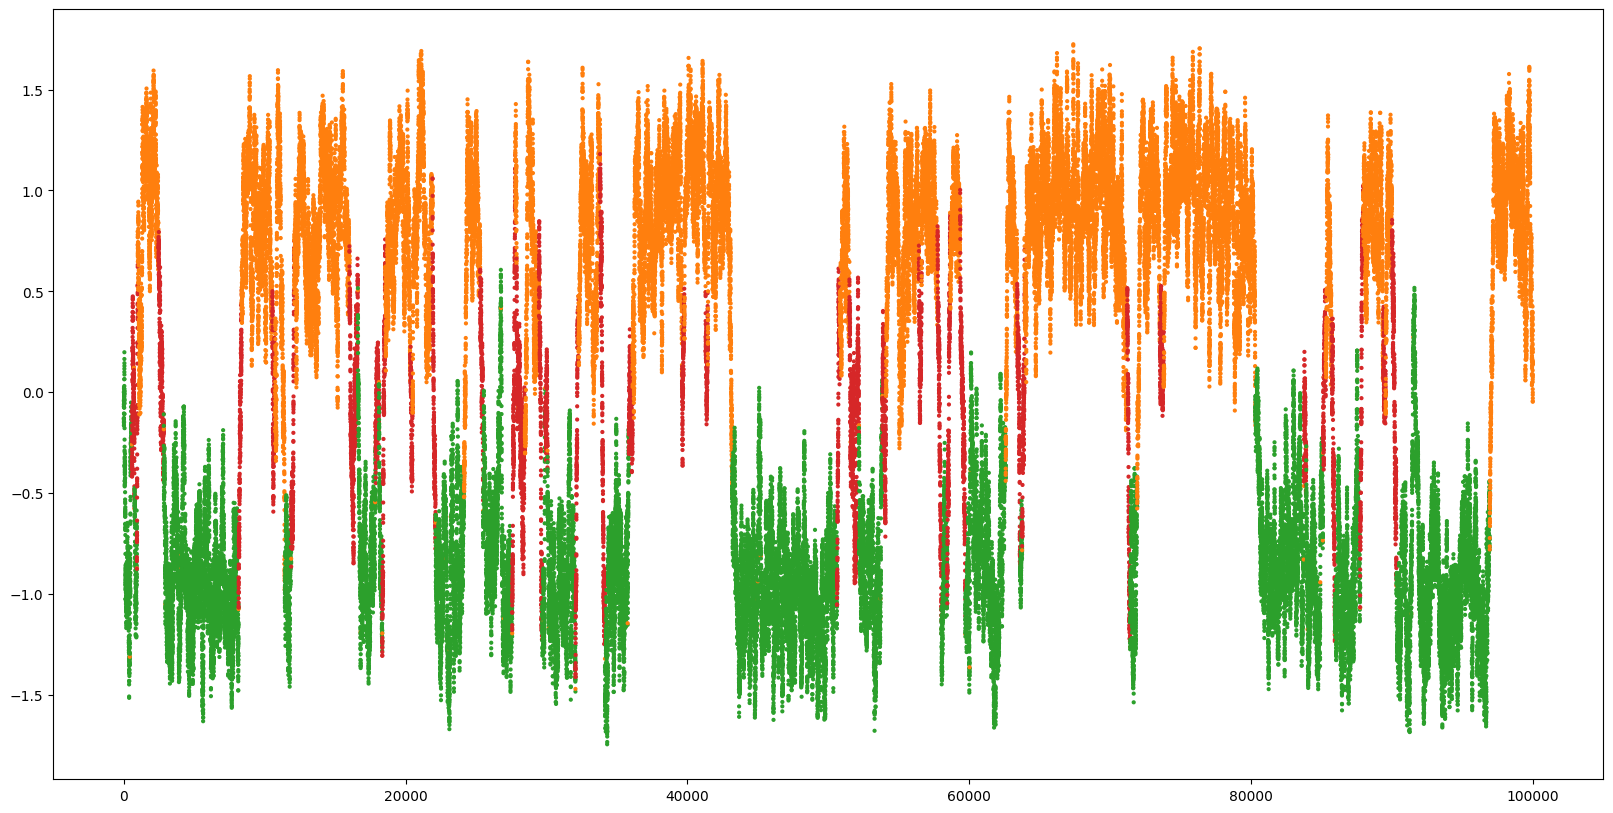

In [9]:
data = adpc_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("langevin-adpc-clustering.pdf")
plt.show()

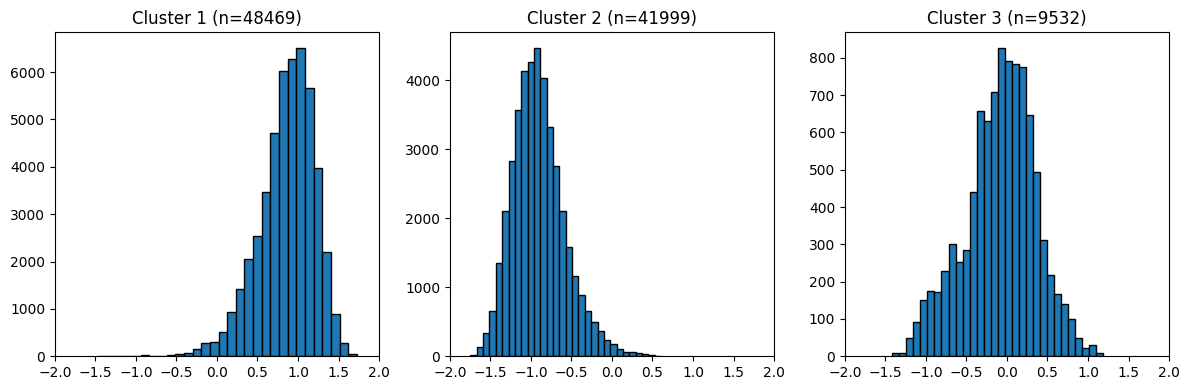

In [10]:
N = 3
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1,3, figsize=(12, 4))
ticks = [-2.0 + n*0.5 for n in range(9)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("langevin-adpc-distributions.pdf")
plt.show()

In [11]:
h = 4
df = adpc_df
N = 3
T = 20000
cps = adpc_sbc.change_points_.flatten()[:T]
df = adpc_df.iloc[:T,:]
cps.shape

(20000,)

In [12]:
from tqdm import tqdm
import ot
def compute_pairwise_segment_distances(X, changes):
    """
    assumes that changes[0] == 0 and changes[-1] == X.shape[0]
    """
    N = changes.shape[0]
    distance_matrix = np.zeros((N - 1, N - 1))
    indices = np.triu_indices_from(distance_matrix)

    for idx in tqdm(zip(indices[0], indices[1]), total=len(indices[0])):
        i, j = idx
        t0 = changes[i]
        t1 = changes[i + 1]
        a = X[t0:t1]

        # TODO: need to safety check against empty segments

        s0 = changes[j]
        s1 = changes[j + 1]
        b = X[s0:s1]

        d = np.sqrt(ot.emd2_1d(a, b))

        distance_matrix[i, j] = d
        distance_matrix[j, i] = d

    return distance_matrix

change_indices = np.array([i for i in range(T) if cps[i] ==1])
D = compute_pairwise_segment_distances(data["value"].to_numpy()[:T], change_indices)

100%|███████████████████████████████████████| 561/561 [00:00<00:00, 7055.27it/s]


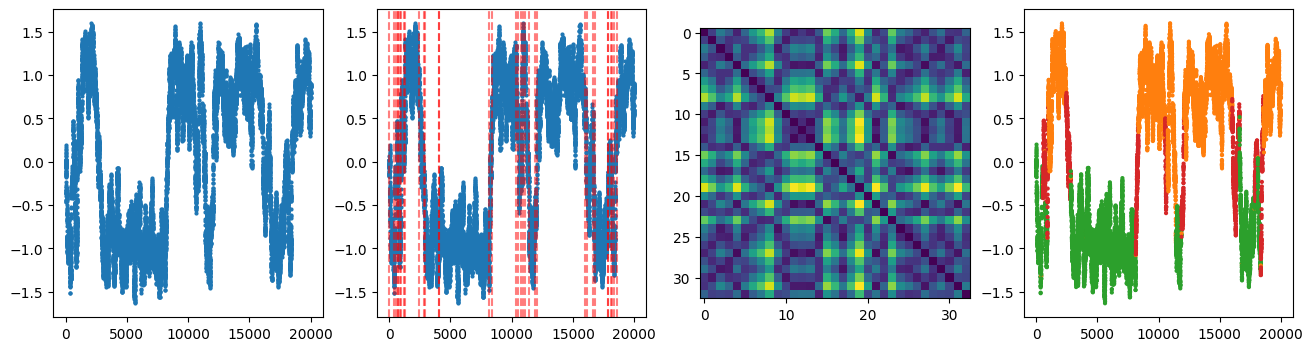

In [13]:
fig, ax = plt.subplots(1,4, figsize=(4*h, h))
ax[0].scatter(df['time'], df['value'], s=4, rasterized=True)
ax[1].scatter(df['time'], df['value'], s=4, rasterized=True)
for t in df['time'][cps == 1]:
   ax[1].axvline(t, color='red', linestyle='--', alpha=0.5, zorder=1)
ax[2].imshow(D)
ax[3].scatter(df['time'], df['value'], c=colors[:T], s=4, rasterized=True)

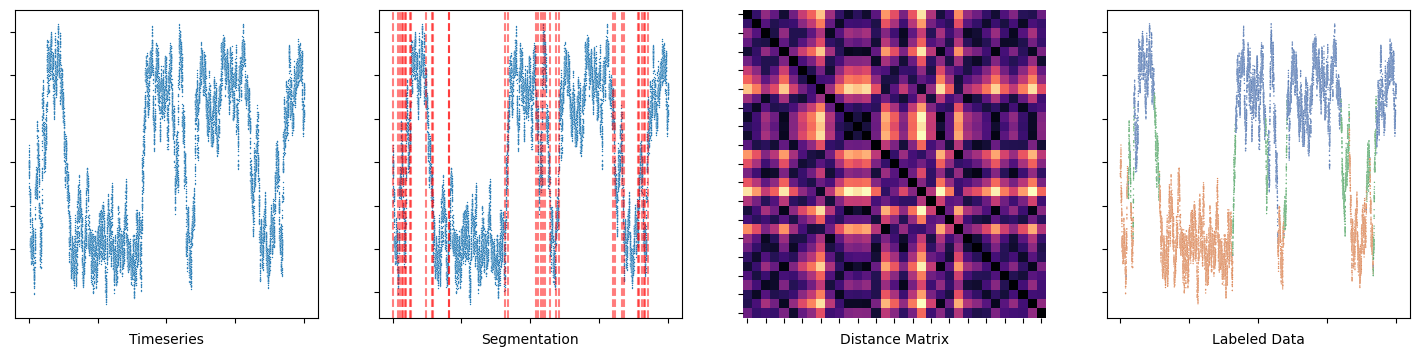

In [12]:
fig, ax = plt.subplots(1,4, figsize=(4.5*h, h))
g1 = sns.scatterplot(df, x='time', y='value', ax=ax[0], s=1)
g2 = sns.scatterplot(df, x='time', y='value', ax=ax[1], s=1)
for t in df['time'][cps == 1]:
   ax[1].axvline(t, color='red', linestyle='--', alpha=0.5, zorder=1)
g3 = sns.heatmap(D, ax=ax[2], cmap='magma', cbar=False)
g4 = sns.scatterplot(df, x='time', y='value', hue='label',ax=ax[3], s=1, palette='deep', legend=False)
g1.set(xticklabels=[], xlabel='Timeseries', yticklabels=[],ylabel=None)
g2.set(xticklabels=[], xlabel='Segmentation', yticklabels=[], ylabel=None)
g3.set(xticklabels=[], xlabel='Distance Matrix', yticklabels=[])
g4.set(xticklabels=[], xlabel='Labeled Data', yticklabels=[],ylabel=None)
plt.savefig('pipeline-illustration.pdf', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

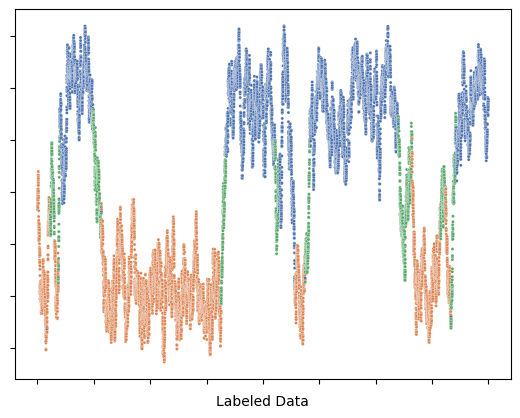

In [13]:
fig, ax = plt.subplots()
s=5
lw=0.5
g1 = sns.lineplot(df, x='time', y='value', ax=ax, lw=lw)#, s=s)
g1.set(xticklabels=[], xlabel='Timeseries', yticklabels=[],ylabel=None)
plt.savefig("timeseries.pdf", bbox_inches="tight")
plt.clf()
fig,ax=plt.subplots()
g2 = sns.lineplot(df, x='time', y='value', ax=ax, lw=lw)#, s=s)
for t in df['time'][cps == 1]:
   ax.axvline(t, color='red', linestyle='--', alpha=0.5, zorder=1)
g2.set(xticklabels=[], xlabel='Segmentation', yticklabels=[], ylabel=None)
plt.savefig("segmentation.pdf", bbox_inches="tight")
plt.clf()
fig,ax=plt.subplots()
g3 = sns.heatmap(D, ax=ax, cmap='viridis', cbar=False)
g3.set(xticklabels=[], xlabel='Distance Matrix', yticklabels=[])
plt.savefig("distmat.pdf", bbox_inches="tight")
plt.clf()
fig,ax=plt.subplots()
g4 = sns.scatterplot(df, x='time', y='value', hue='label',ax=ax, s=s, palette='deep', legend=False)
g4.set(xticklabels=[], xlabel='Labeled Data', yticklabels=[],ylabel=None)
g4.set(xticklabels=[], xlabel='Labeled Data', yticklabels=[],ylabel=None)
plt.savefig("labels.pdf", bbox_inches="tight")

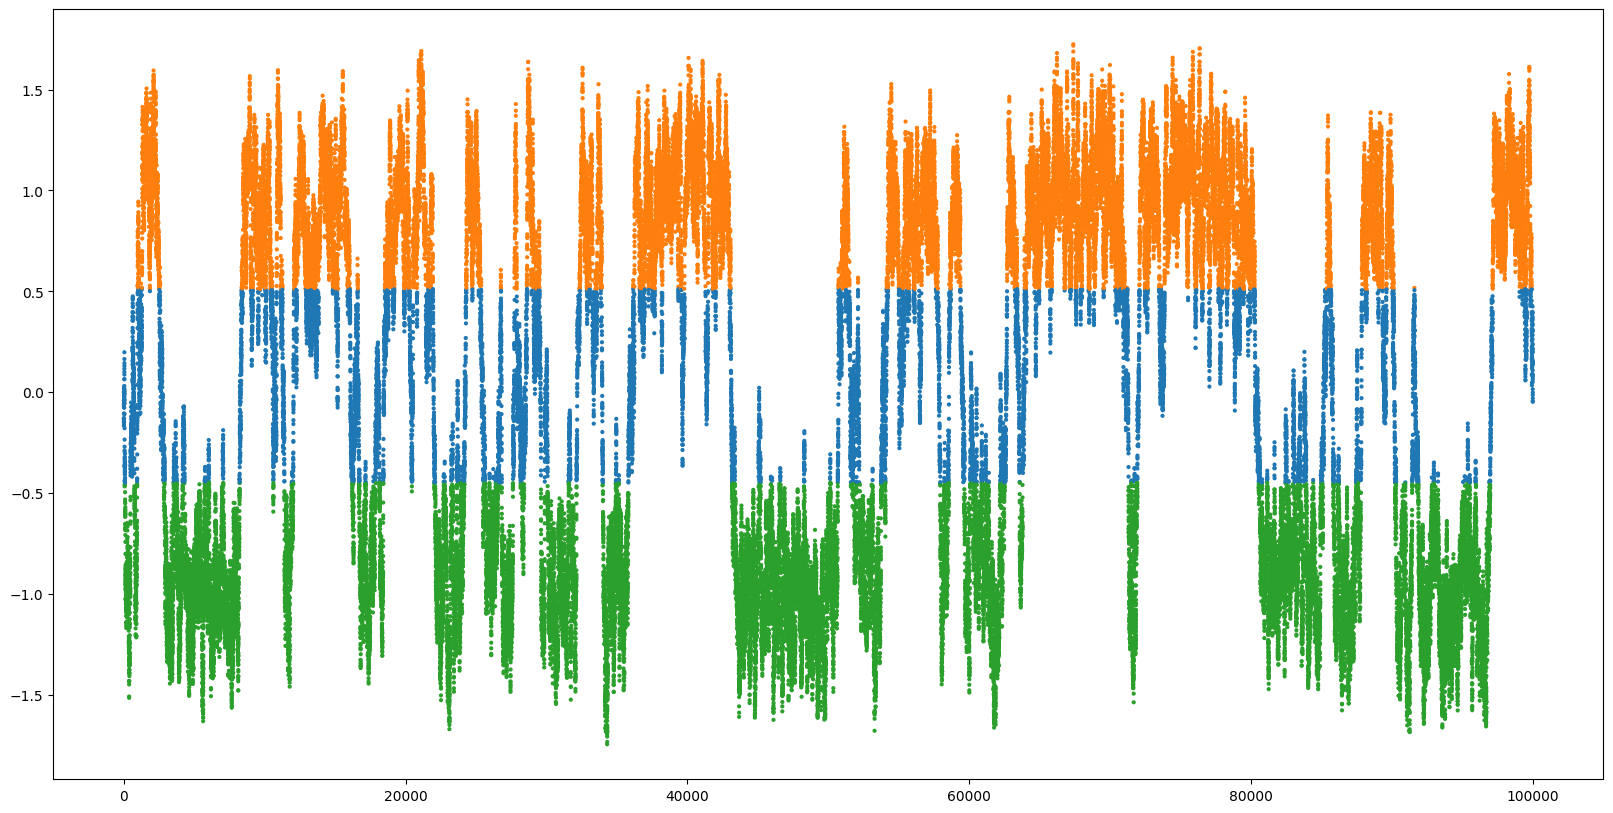

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(init="k-means++", n_clusters=3, n_init=4)
kmeans.fit(x)
kmeans.labels_.reshape(-1,1).shape

kmeans_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": kmeans.labels_})
data = kmeans_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("langevin-kmeans-clustering.pdf", bbox_inches="tight")
plt.show()

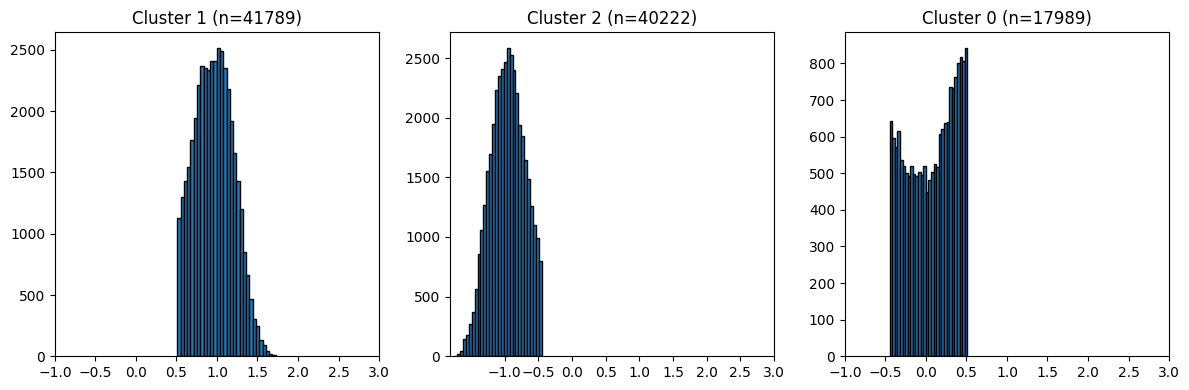

In [15]:
data = kmeans_df
N = 3
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1,3, figsize=(12, 4))
ticks = [-1.0 + n*0.5 for n in range(9)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("langevin-kmeans-distributions.pdf")
plt.show()